# Firmenvergleich - Mengenanalyse mit Fuzzy Matching

Dieses Notebook analysiert die Schnittmengen und Unterschiede zwischen den Firmenlisten aus drei Sparten.

**NEU:** Das Notebook erkennt jetzt auch ähnliche Firmennamen (z.B. "DB Station&Service AG" vs. "DB Station & Service AG") als Duplikate.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3, venn3_circles
import numpy as np
from rapidfuzz import fuzz, process
import re

## 1. Daten einlesen

In [3]:
# Excel-Datei einlesen
df = pd.read_excel('data/Firmenvergleich.xlsx', sheet_name=0)

# Struktur der Daten anzeigen
print("Spalten in der Datei:")
print(df.columns.tolist())
print(f"\nAnzahl Zeilen: {len(df)}")
print("\nErste Zeilen:")
df.head(10)

Spalten in der Datei:
['Firmen Industrie', 'Firmen Dienstleistungsmanagement', 'Firmen Spedition & Logistik']

Anzahl Zeilen: 87

Erste Zeilen:


,Firmen Industrie,Firmen Dienstleistungsmanagement,Firmen Spedition & Logistik
0,50Hertz Transmission GmbH,Amazon Fufillment Germany GmbH,A. Menarini Research & Business Service GmbH
1,Abionik Group GmbH,Amazon Gera GmbH,Amazon Distribution GmbH
2,Actemium BEA GmbH,Amazon Koblenz GmbH,Amazon Gera GmbH
3,Actemium Energy Projects GmbH,B&O Service Berlin GmbH,Amazon Helmstedt GmbH
4,ALBA Berlin GmbH,BASF Services Europe GmbH,Amazon Logistik Achim GmbH
5,ALSTOM Transportation Germany GmbH,BEEFTEA group GmbH,Amazon Logistik Winsen GmbH
6,Askona Ventures GmbH,Berlin Cuisine Jensen GmbH,CHARITÉ CFM Facility Management GmbH
7,ASML Berlin GmbH,Berlin Partner für Wirtschaft und Technologie ...,DACHSER SE Logistikzentrum Berlin Brandenbg
8,August Storck KG,Berliner Stadtreinigung - BSR,Dachser SE-Logistikzentrum BB
9,B·R·A·H·M·S GmbH,Berliner Stadtreinigungsbetriebe AöR,DB Engineering & Consulting GmbH


In [5]:
print("Alle Firmen:")
pd.set_option('display.max_rows', None)
df

Alle Firmen:


,Firmen Industrie,Firmen Dienstleistungsmanagement,Firmen Spedition & Logistik
0,50Hertz Transmission GmbH,Amazon Fufillment Germany GmbH,A. Menarini Research & Business Service GmbH
1,Abionik Group GmbH,Amazon Gera GmbH,Amazon Distribution GmbH
2,Actemium BEA GmbH,Amazon Koblenz GmbH,Amazon Gera GmbH
3,Actemium Energy Projects GmbH,B&O Service Berlin GmbH,Amazon Helmstedt GmbH
4,ALBA Berlin GmbH,BASF Services Europe GmbH,Amazon Logistik Achim GmbH
5,ALSTOM Transportation Germany GmbH,BEEFTEA group GmbH,Amazon Logistik Winsen GmbH
6,Askona Ventures GmbH,Berlin Cuisine Jensen GmbH,CHARITÉ CFM Facility Management GmbH
7,ASML Berlin GmbH,Berlin Partner für Wirtschaft und Technologie ...,DACHSER SE Logistikzentrum Berlin Brandenbg
8,August Storck KG,Berliner Stadtreinigung - BSR,Dachser SE-Logistikzentrum BB
9,B·R·A·H·M·S GmbH,Berliner Stadtreinigungsbetriebe AöR,DB Engineering & Consulting GmbH


## 2. Funktionen für Normalisierung und Fuzzy Matching

In [6]:
def normalize_company_name(name):
    """
    Normalisiert Firmennamen für besseren Vergleich:
    - Entfernt mehrfache Leerzeichen
    - Konvertiert zu Kleinbuchstaben
    - Normalisiert Rechtsformen
    - Entfernt Sonderzeichen
    """
    if pd.isna(name) or name == '':
        return None
    
    # Zu String konvertieren und strippen
    name = str(name).strip()
    
    # Kleinbuchstaben
    name = name.lower()
    
    # Mehrfache Leerzeichen entfernen
    name = re.sub(r'\s+', ' ', name)
    
    # Sonderzeichen normalisieren (aber behalten für Matching)
    # name = re.sub(r'[&]', 'und', name)
    
    return name


def find_similar_companies(companies_list, similarity_threshold=85):
    """
    Findet ähnliche Firmennamen in einer Liste.
    Returns: Dictionary mit Original -> kanonischer Name Mapping
    """
    if not companies_list:
        return {}, []
    
    # Liste zu Liste konvertieren falls Set
    companies = list(companies_list)
    
    # Mapping: Original-Name -> kanonischer Name (kürzester oder häufigster)
    name_mapping = {}
    similar_groups = []
    processed = set()
    
    for i, company1 in enumerate(companies):
        if company1 in processed:
            continue
            
        similar_group = [company1]
        normalized1 = normalize_company_name(company1)
        
        if normalized1 is None:
            continue
        
        # Vergleiche mit allen anderen Firmen
        for j, company2 in enumerate(companies[i+1:], start=i+1):
            if company2 in processed:
                continue
                
            normalized2 = normalize_company_name(company2)
            if normalized2 is None:
                continue
            
            # Berechne Ähnlichkeit
            similarity = fuzz.ratio(normalized1, normalized2)
            
            if similarity >= similarity_threshold:
                similar_group.append(company2)
                processed.add(company2)
        
        # Wähle kanonischen Namen (kürzesten oder ersten)
        canonical_name = min(similar_group, key=lambda x: (len(x), x))
        
        for name in similar_group:
            name_mapping[name] = canonical_name
        
        processed.add(company1)
        
        # Nur Gruppen mit mehreren Einträgen merken
        if len(similar_group) > 1:
            similar_groups.append(similar_group)
    
    return name_mapping, similar_groups


def fuzzy_match_across_sets(set1, set2, similarity_threshold=85):
    """
    Findet Matches zwischen zwei Sets mit Fuzzy Matching.
    Returns: Set von Tupeln (name_from_set1, name_from_set2)
    """
    matches = set()
    
    for name1 in set1:
        normalized1 = normalize_company_name(name1)
        if normalized1 is None:
            continue
            
        for name2 in set2:
            normalized2 = normalize_company_name(name2)
            if normalized2 is None:
                continue
            
            similarity = fuzz.ratio(normalized1, normalized2)
            
            if similarity >= similarity_threshold:
                matches.add((name1, name2))
    
    return matches


print("Funktionen geladen!")
print(f"\nBeispiel: normalize_company_name('DB Station&Service AG') = '{normalize_company_name('DB Station&Service AG')}'")
print(f"Beispiel: normalize_company_name('DB Station & Service AG') = '{normalize_company_name('DB Station & Service AG')}'")

Funktionen geladen!

Beispiel: normalize_company_name('DB Station&Service AG') = 'db station&service ag'
Beispiel: normalize_company_name('DB Station & Service AG') = 'db station & service ag'


## 3. Konfiguration: Similarity-Threshold einstellen

In [7]:
# HIER KANNST DU DEN THRESHOLD ANPASSEN!
# 100 = exaktes Matching (alte Methode)
# 85-95 = empfohlen für Firmennamen mit kleinen Unterschieden
# < 85 = sehr tolerant, aber mehr False Positives

SIMILARITY_THRESHOLD = 85

print(f"Verwende Similarity-Threshold: {SIMILARITY_THRESHOLD}%")
print("\nHinweis: Je niedriger der Wert, desto mehr ähnliche Firmen werden als identisch erkannt.")
print("         Je höher der Wert, desto strenger die Prüfung.")

Verwende Similarity-Threshold: 85%

Hinweis: Je niedriger der Wert, desto mehr ähnliche Firmen werden als identisch erkannt.
         Je höher der Wert, desto strenger die Prüfung.


## 4. Daten bereinigen und Duplikate innerhalb Sparten finden

In [8]:
# Spaltennamen
col_names = df.columns.tolist()
sparte1_name = col_names[0]
sparte2_name = col_names[1]
sparte3_name = col_names[2]

# Originale Sets erstellen (wie vorher)
sparte1_raw = set(df[sparte1_name].dropna().astype(str).str.strip())
sparte2_raw = set(df[sparte2_name].dropna().astype(str).str.strip())
sparte3_raw = set(df[sparte3_name].dropna().astype(str).str.strip())

# Leere Strings entfernen
sparte1_raw = {x for x in sparte1_raw if x != ''}
sparte2_raw = {x for x in sparte2_raw if x != ''}
sparte3_raw = {x for x in sparte3_raw if x != ''}

print("ORIGINALE ZAHLEN (vor Duplikatserkennung):")
print("=" * 60)
print(f"{sparte1_name}: {len(sparte1_raw)} Firmen")
print(f"{sparte2_name}: {len(sparte2_raw)} Firmen")
print(f"{sparte3_name}: {len(sparte3_raw)} Firmen")

# Duplikate innerhalb jeder Sparte finden
print("\n" + "=" * 60)
print("DUPLIKATE INNERHALB DER SPARTEN ERKENNEN")
print("=" * 60)

mapping1, groups1 = find_similar_companies(sparte1_raw, SIMILARITY_THRESHOLD)
mapping2, groups2 = find_similar_companies(sparte2_raw, SIMILARITY_THRESHOLD)
mapping3, groups3 = find_similar_companies(sparte3_raw, SIMILARITY_THRESHOLD)

# Bereinigte Sets erstellen (mit kanonischen Namen)
sparte1_clean = {mapping1.get(x, x) for x in sparte1_raw}
sparte2_clean = {mapping2.get(x, x) for x in sparte2_raw}
sparte3_clean = {mapping3.get(x, x) for x in sparte3_raw}

print(f"\n{sparte1_name}: {len(groups1)} Duplikat-Gruppen gefunden")
if groups1:
    for i, group in enumerate(groups1, 1):
        print(f"  Gruppe {i}: {len(group)} ähnliche Namen")
        for name in sorted(group):
            print(f"    - {name}")

print(f"\n{sparte2_name}: {len(groups2)} Duplikat-Gruppen gefunden")
if groups2:
    for i, group in enumerate(groups2, 1):
        print(f"  Gruppe {i}: {len(group)} ähnliche Namen")
        for name in sorted(group):
            print(f"    - {name}")

print(f"\n{sparte3_name}: {len(groups3)} Duplikat-Gruppen gefunden")
if groups3:
    for i, group in enumerate(groups3, 1):
        print(f"  Gruppe {i}: {len(group)} ähnliche Namen")
        for name in sorted(group):
            print(f"    - {name}")

print("\n" + "=" * 60)
print("BEREINIGTE ZAHLEN (nach Duplikatserkennung):")
print("=" * 60)
print(f"{sparte1_name}: {len(sparte1_clean)} eindeutige Firmen")
print(f"{sparte2_name}: {len(sparte2_clean)} eindeutige Firmen")
print(f"{sparte3_name}: {len(sparte3_clean)} eindeutige Firmen")

ORIGINALE ZAHLEN (vor Duplikatserkennung):
Firmen Industrie: 87 Firmen
Firmen Dienstleistungsmanagement: 48 Firmen
Firmen Spedition & Logistik: 45 Firmen

DUPLIKATE INNERHALB DER SPARTEN ERKENNEN

Firmen Industrie: 3 Duplikat-Gruppen gefunden
  Gruppe 1: 2 ähnliche Namen
    - DP NL Betrieb Berlin 1
    - DP NL Betrieb Berlin 2
  Gruppe 2: 2 ähnliche Namen
    - ALBA Berlin GmbH
    - ASML Berlin GmbH
  Gruppe 3: 2 ähnliche Namen
    - Märkische Geflügelhof-Spezialitäten GmbH
    - Märkische Geflügenhof-Spezialitäten GmbH

Firmen Dienstleistungsmanagement: 1 Duplikat-Gruppen gefunden
  Gruppe 1: 2 ähnliche Namen
    - DB Station & Service
    - DB Station & Service AG

Firmen Spedition & Logistik: 2 Duplikat-Gruppen gefunden
  Gruppe 1: 3 ähnliche Namen
    - Deutsche Post AG Niederlassung BRIEF Berlin II
    - Deutsche Post AG Niederlassung Betrieb Berlin 1
    - Deutsche Post AG Niederlassung Betrieb Berlin 2
  Gruppe 2: 2 ähnliche Namen
    - Deutsche Post AG NL Betrieb Dresden
    

## 5. Mengenvergleich mit Fuzzy Matching über Sparten hinweg

In [9]:
# Fuzzy Matches zwischen den Sparten finden
print("FUZZY MATCHING ZWISCHEN SPARTEN")
print("=" * 60)

matches_1_2 = fuzzy_match_across_sets(sparte1_clean, sparte2_clean, SIMILARITY_THRESHOLD)
matches_1_3 = fuzzy_match_across_sets(sparte1_clean, sparte3_clean, SIMILARITY_THRESHOLD)
matches_2_3 = fuzzy_match_across_sets(sparte2_clean, sparte3_clean, SIMILARITY_THRESHOLD)

print(f"\nMatches {sparte1_name} <-> {sparte2_name}: {len(matches_1_2)}")
if matches_1_2:
    for name1, name2 in sorted(matches_1_2):
        if name1 != name2:  # Nur zeigen wenn sie unterschiedlich sind
            print(f"  '{name1}' ≈ '{name2}'")

print(f"\nMatches {sparte1_name} <-> {sparte3_name}: {len(matches_1_3)}")
if matches_1_3:
    for name1, name3 in sorted(matches_1_3):
        if name1 != name3:
            print(f"  '{name1}' ≈ '{name3}'")

print(f"\nMatches {sparte2_name} <-> {sparte3_name}: {len(matches_2_3)}")
if matches_2_3:
    for name2, name3 in sorted(matches_2_3):
        if name2 != name3:
            print(f"  '{name2}' ≈ '{name3}'")

# Für Mengenoperationen: alle ähnlichen Namen zusammenfassen
# Erstelle Sets mit kanonischen Namen für jede Sparte
sparte1_for_comparison = sparte1_clean.copy()
sparte2_for_comparison = sparte2_clean.copy()
sparte3_for_comparison = sparte3_clean.copy()

# Füge die Matches hinzu (verwende immer den Namen aus Sparte 1 als "kanonisch" wenn vorhanden)
cross_mapping = {}
for name1, name2 in matches_1_2:
    cross_mapping[name2] = name1
for name1, name3 in matches_1_3:
    cross_mapping[name3] = name1
# Für 2-3 Matches: verwende Sparte 2 als Referenz wenn kein Sparte 1 Match
for name2, name3 in matches_2_3:
    if name3 not in cross_mapping:
        cross_mapping[name3] = name2

# Sparte 2 und 3 auf gemeinsame Namen mappen
sparte2_mapped = {cross_mapping.get(x, x) for x in sparte2_for_comparison}
sparte3_mapped = {cross_mapping.get(x, x) for x in sparte3_for_comparison}

FUZZY MATCHING ZWISCHEN SPARTEN

Matches Firmen Industrie <-> Firmen Dienstleistungsmanagement: 5
  'DB Station&Service AG' ≈ 'DB Station & Service'
  'Stadtwerke Prenzlau GmbH' ≈ 'Stadtwerke Bernau GmbH'

Matches Firmen Industrie <-> Firmen Spedition & Logistik: 3

Matches Firmen Dienstleistungsmanagement <-> Firmen Spedition & Logistik: 8
  'Deutsche Post AG Niederlassung Betrieb Berlin 2' ≈ 'Deutsche Post AG Niederlassung BRIEF Berlin II'


## 6. Mengenoperationen durchführen

In [10]:
# Jetzt Mengenoperationen auf den gemappten Sets
alle_drei = sparte1_for_comparison & sparte2_mapped & sparte3_mapped
nur_1_und_2 = (sparte1_for_comparison & sparte2_mapped) - sparte3_mapped
nur_1_und_3 = (sparte1_for_comparison & sparte3_mapped) - sparte2_mapped
nur_2_und_3 = (sparte2_mapped & sparte3_mapped) - sparte1_for_comparison

nur_sparte1 = sparte1_for_comparison - sparte2_mapped - sparte3_mapped
nur_sparte2 = sparte2_mapped - sparte1_for_comparison - sparte3_mapped
nur_sparte3 = sparte3_mapped - sparte1_for_comparison - sparte2_mapped

print("=" * 60)
print("MENGENANALYSE (MIT FUZZY MATCHING)")
print("=" * 60)
print(f"\nIn allen drei Sparten: {len(alle_drei)} Firmen")
print(f"\nIn genau zwei Sparten:")
print(f"  - {sparte1_name} ∩ {sparte2_name} (ohne {sparte3_name}): {len(nur_1_und_2)} Firmen")
print(f"  - {sparte1_name} ∩ {sparte3_name} (ohne {sparte2_name}): {len(nur_1_und_3)} Firmen")
print(f"  - {sparte2_name} ∩ {sparte3_name} (ohne {sparte1_name}): {len(nur_2_und_3)} Firmen")
print(f"\nNur in einer Sparte:")
print(f"  - Nur {sparte1_name}: {len(nur_sparte1)} Firmen")
print(f"  - Nur {sparte2_name}: {len(nur_sparte2)} Firmen")
print(f"  - Nur {sparte3_name}: {len(nur_sparte3)} Firmen")
print(f"\nGesamtanzahl eindeutiger Firmen: {len(sparte1_for_comparison | sparte2_mapped | sparte3_mapped)}")

MENGENANALYSE (MIT FUZZY MATCHING)

In allen drei Sparten: 2 Firmen

In genau zwei Sparten:
  - Firmen Industrie ∩ Firmen Dienstleistungsmanagement (ohne Firmen Spedition & Logistik): 3 Firmen
  - Firmen Industrie ∩ Firmen Spedition & Logistik (ohne Firmen Dienstleistungsmanagement): 1 Firmen
  - Firmen Dienstleistungsmanagement ∩ Firmen Spedition & Logistik (ohne Firmen Industrie): 6 Firmen

Nur in einer Sparte:
  - Nur Firmen Industrie: 78 Firmen
  - Nur Firmen Dienstleistungsmanagement: 36 Firmen
  - Nur Firmen Spedition & Logistik: 33 Firmen

Gesamtanzahl eindeutiger Firmen: 159


## 7. Vergleich: Exakt vs. Fuzzy Matching

In [11]:
# Zum Vergleich: exakte Mengenoperationen auf bereinigten (aber nicht gemappten) Sets
alle_drei_exakt = sparte1_clean & sparte2_clean & sparte3_clean
nur_1_und_2_exakt = (sparte1_clean & sparte2_clean) - sparte3_clean
nur_1_und_3_exakt = (sparte1_clean & sparte3_clean) - sparte2_clean
nur_2_und_3_exakt = (sparte2_clean & sparte3_clean) - sparte1_clean

print("=" * 60)
print("VERGLEICH: EXAKT vs. FUZZY")
print("=" * 60)
print(f"\nIn allen drei Sparten:")
print(f"  Exakt:  {len(alle_drei_exakt)} Firmen")
print(f"  Fuzzy:  {len(alle_drei)} Firmen")
print(f"  Gewinn: +{len(alle_drei) - len(alle_drei_exakt)} Firmen")

print(f"\nIn genau zwei Sparten (Sparte 1 ∩ Sparte 2):")
print(f"  Exakt:  {len(nur_1_und_2_exakt)} Firmen")
print(f"  Fuzzy:  {len(nur_1_und_2)} Firmen")
print(f"  Gewinn: {len(nur_1_und_2) - len(nur_1_und_2_exakt):+d} Firmen")

print(f"\nIn genau zwei Sparten (Sparte 1 ∩ Sparte 3):")
print(f"  Exakt:  {len(nur_1_und_3_exakt)} Firmen")
print(f"  Fuzzy:  {len(nur_1_und_3)} Firmen")
print(f"  Gewinn: {len(nur_1_und_3) - len(nur_1_und_3_exakt):+d} Firmen")

print(f"\nIn genau zwei Sparten (Sparte 2 ∩ Sparte 3):")
print(f"  Exakt:  {len(nur_2_und_3_exakt)} Firmen")
print(f"  Fuzzy:  {len(nur_2_und_3)} Firmen")
print(f"  Gewinn: {len(nur_2_und_3) - len(nur_2_und_3_exakt):+d} Firmen")

VERGLEICH: EXAKT vs. FUZZY

In allen drei Sparten:
  Exakt:  2 Firmen
  Fuzzy:  2 Firmen
  Gewinn: +0 Firmen

In genau zwei Sparten (Sparte 1 ∩ Sparte 2):
  Exakt:  1 Firmen
  Fuzzy:  3 Firmen
  Gewinn: +2 Firmen

In genau zwei Sparten (Sparte 1 ∩ Sparte 3):
  Exakt:  1 Firmen
  Fuzzy:  1 Firmen
  Gewinn: +0 Firmen

In genau zwei Sparten (Sparte 2 ∩ Sparte 3):
  Exakt:  5 Firmen
  Fuzzy:  6 Firmen
  Gewinn: +1 Firmen


## 8. Details zu den Firmen

In [12]:
def zeige_firmen(firmen_set, titel, max_anzeige=20):
    print(f"\n{titel} ({len(firmen_set)} Firmen):")
    print("-" * 60)
    if len(firmen_set) == 0:
        print("  (keine)")
    else:
        sorted_firmen = sorted(list(firmen_set))
        for i, firma in enumerate(sorted_firmen[:max_anzeige], 1):
            print(f"  {i}. {firma}")
        if len(firmen_set) > max_anzeige:
            print(f"  ... und {len(firmen_set) - max_anzeige} weitere")

zeige_firmen(alle_drei, "Firmen in allen drei Sparten", max_anzeige=30)
zeige_firmen(nur_1_und_2, f"Firmen in {sparte1_name} UND {sparte2_name} (ohne {sparte3_name})", max_anzeige=20)
zeige_firmen(nur_1_und_3, f"Firmen in {sparte1_name} UND {sparte3_name} (ohne {sparte2_name})", max_anzeige=20)
zeige_firmen(nur_2_und_3, f"Firmen in {sparte2_name} UND {sparte3_name} (ohne {sparte1_name})", max_anzeige=20)


Firmen in allen drei Sparten (2 Firmen):
------------------------------------------------------------
  1. DB Engineering & Consulting GmbH
  2. Deutsche Post AG

Firmen in Firmen Industrie UND Firmen Dienstleistungsmanagement (ohne Firmen Spedition & Logistik) (3 Firmen):
------------------------------------------------------------
  1. BASF Services Europe GmbH
  2. DB Station&Service AG
  3. Stadtwerke Prenzlau GmbH

Firmen in Firmen Industrie UND Firmen Spedition & Logistik (ohne Firmen Dienstleistungsmanagement) (1 Firmen):
------------------------------------------------------------
  1. profine GmbH

Firmen in Firmen Dienstleistungsmanagement UND Firmen Spedition & Logistik (ohne Firmen Industrie) (6 Firmen):
------------------------------------------------------------
  1. Amazon Gera GmbH
  2. CHARITÉ CFM Facility Management GmbH
  3. Deutsche Post AG Niederlassung Betrieb Berlin 2
  4. Mercedes-Benz Group Services Berlin GmbH
  5. REWE Markt GmbH
  6. Stadtwerke Potsdam GmbH

## 9. Venn-Diagramm

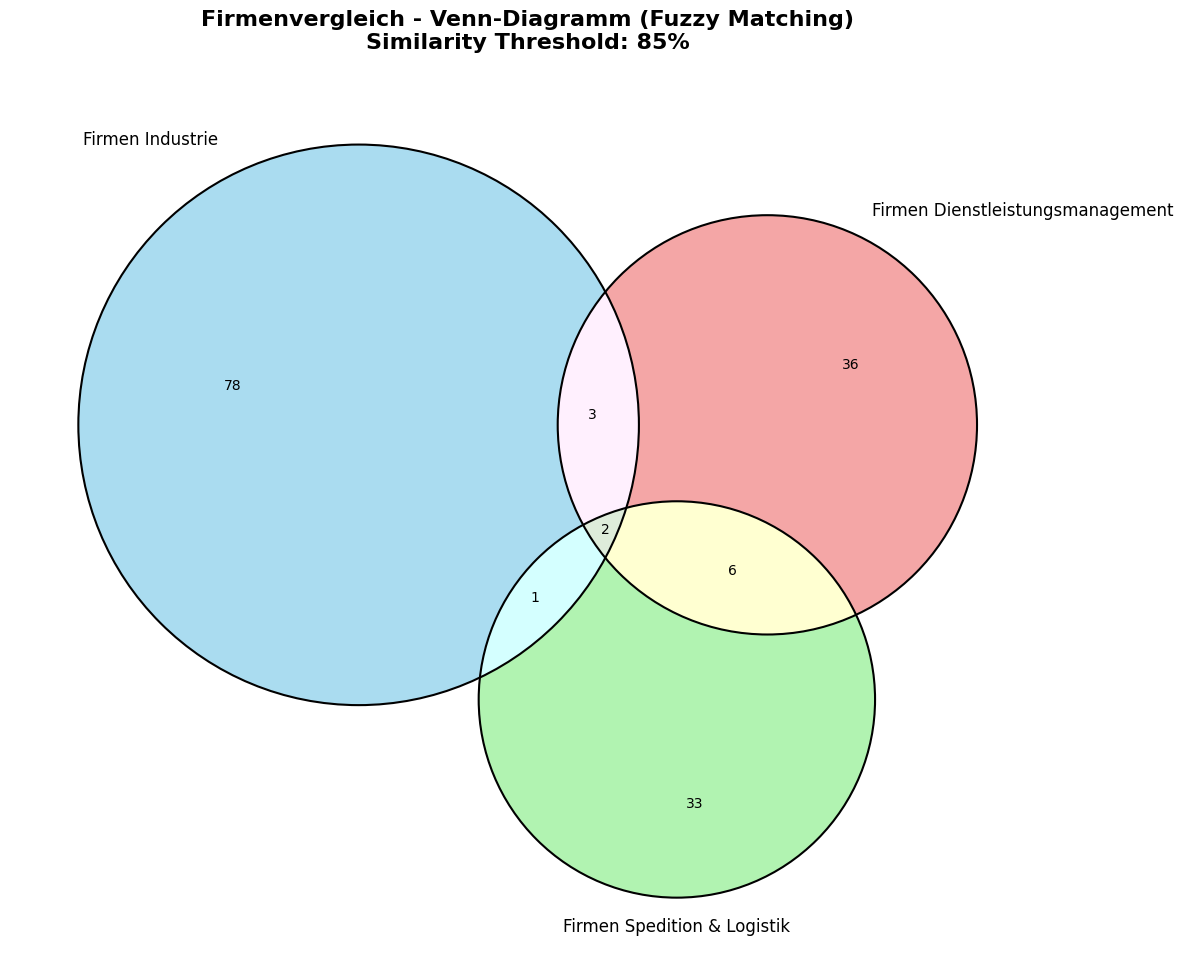


ZUSAMMENFASSUNG
Gesamtanzahl eindeutiger Firmen: 159

Abdeckung:
  - Firmen Industrie: 84 (52.8%)
  - Firmen Dienstleistungsmanagement: 47 (29.6%)
  - Firmen Spedition & Logistik: 42 (26.4%)

Überlappung:
  - In allen drei Sparten: 2 (1.3%)
  - In mindestens zwei Sparten: 12 Firmen
  - Nur in einer Sparte: 147 Firmen


In [13]:
# Venn-Diagramm erstellen
plt.figure(figsize=(12, 10))

venn = venn3(
    [sparte1_for_comparison, sparte2_mapped, sparte3_mapped],
    set_labels=(sparte1_name, sparte2_name, sparte3_name),
    set_colors=('skyblue', 'lightcoral', 'lightgreen'),
    alpha=0.7
)

venn3_circles([sparte1_for_comparison, sparte2_mapped, sparte3_mapped], linewidth=1.5)

plt.title(f'Firmenvergleich - Venn-Diagramm (Fuzzy Matching)\nSimilarity Threshold: {SIMILARITY_THRESHOLD}%', 
          fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# Statistik
print("\n" + "=" * 60)
print("ZUSAMMENFASSUNG")
print("=" * 60)
total_unique = len(sparte1_for_comparison | sparte2_mapped | sparte3_mapped)
print(f"Gesamtanzahl eindeutiger Firmen: {total_unique}")
print(f"\nAbdeckung:")
print(f"  - {sparte1_name}: {len(sparte1_for_comparison)} ({len(sparte1_for_comparison)/total_unique*100:.1f}%)")
print(f"  - {sparte2_name}: {len(sparte2_mapped)} ({len(sparte2_mapped)/total_unique*100:.1f}%)")
print(f"  - {sparte3_name}: {len(sparte3_mapped)} ({len(sparte3_mapped)/total_unique*100:.1f}%)")
print(f"\nÜberlappung:")
print(f"  - In allen drei Sparten: {len(alle_drei)} ({len(alle_drei)/total_unique*100:.1f}%)")
print(f"  - In mindestens zwei Sparten: {len(alle_drei) + len(nur_1_und_2) + len(nur_1_und_3) + len(nur_2_und_3)} Firmen")
print(f"  - Nur in einer Sparte: {len(nur_sparte1) + len(nur_sparte2) + len(nur_sparte3)} Firmen")

## 10. Export der Ergebnisse

In [14]:
import os
os.makedirs('results', exist_ok=True)

output_path = f'results/mengenanalyse_fuzzy_{SIMILARITY_THRESHOLD}.xlsx'

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    # Alle drei Sparten
    if len(alle_drei) > 0:
        pd.DataFrame(sorted(list(alle_drei)), columns=['Firma']).to_excel(
            writer, sheet_name='Alle_drei_Sparten', index=False
        )
    
    # Zwei Sparten Kombinationen
    if len(nur_1_und_2) > 0:
        pd.DataFrame(sorted(list(nur_1_und_2)), columns=['Firma']).to_excel(
            writer, sheet_name='Sparte1_und_2', index=False
        )
    
    if len(nur_1_und_3) > 0:
        pd.DataFrame(sorted(list(nur_1_und_3)), columns=['Firma']).to_excel(
            writer, sheet_name='Sparte1_und_3', index=False
        )
    
    if len(nur_2_und_3) > 0:
        pd.DataFrame(sorted(list(nur_2_und_3)), columns=['Firma']).to_excel(
            writer, sheet_name='Sparte2_und_3', index=False
        )
    
    # Nur einzelne Sparten
    if len(nur_sparte1) > 0:
        pd.DataFrame(sorted(list(nur_sparte1)), columns=['Firma']).to_excel(
            writer, sheet_name='Nur_Sparte1', index=False
        )
    
    if len(nur_sparte2) > 0:
        pd.DataFrame(sorted(list(nur_sparte2)), columns=['Firma']).to_excel(
            writer, sheet_name='Nur_Sparte2', index=False
        )
    
    if len(nur_sparte3) > 0:
        pd.DataFrame(sorted(list(nur_sparte3)), columns=['Firma']).to_excel(
            writer, sheet_name='Nur_Sparte3', index=False
        )
    
    # Gefundene Duplikate
    duplikat_data = []
    for i, group in enumerate(groups1 + groups2 + groups3, 1):
        for name in group:
            duplikat_data.append({'Gruppe': i, 'Firmenname': name})
    
    if duplikat_data:
        pd.DataFrame(duplikat_data).to_excel(writer, sheet_name='Gefundene_Duplikate', index=False)
    
    # Cross-Matches zwischen Sparten
    cross_match_data = []
    for name1, name2 in matches_1_2:
        if name1 != name2:
            cross_match_data.append({
                'Sparte_1': sparte1_name,
                'Name_1': name1,
                'Sparte_2': sparte2_name,
                'Name_2': name2
            })
    for name1, name3 in matches_1_3:
        if name1 != name3:
            cross_match_data.append({
                'Sparte_1': sparte1_name,
                'Name_1': name1,
                'Sparte_2': sparte3_name,
                'Name_2': name3
            })
    for name2, name3 in matches_2_3:
        if name2 != name3:
            cross_match_data.append({
                'Sparte_1': sparte2_name,
                'Name_1': name2,
                'Sparte_2': sparte3_name,
                'Name_2': name3
            })
    
    if cross_match_data:
        pd.DataFrame(cross_match_data).to_excel(writer, sheet_name='Cross_Sparten_Matches', index=False)
    
    # Zusammenfassung
    summary_data = {
        'Kategorie': [
            f'Gesamt {sparte1_name}',
            f'Gesamt {sparte2_name}',
            f'Gesamt {sparte3_name}',
            'In allen drei Sparten',
            f'{sparte1_name} ∩ {sparte2_name}',
            f'{sparte1_name} ∩ {sparte3_name}',
            f'{sparte2_name} ∩ {sparte3_name}',
            f'Nur {sparte1_name}',
            f'Nur {sparte2_name}',
            f'Nur {sparte3_name}',
            'Gesamtanzahl eindeutig',
            'Similarity Threshold',
            'Duplikate in Sparte 1',
            'Duplikate in Sparte 2',
            'Duplikate in Sparte 3'
        ],
        'Anzahl': [
            len(sparte1_for_comparison),
            len(sparte2_mapped),
            len(sparte3_mapped),
            len(alle_drei),
            len(nur_1_und_2),
            len(nur_1_und_3),
            len(nur_2_und_3),
            len(nur_sparte1),
            len(nur_sparte2),
            len(nur_sparte3),
            total_unique,
            SIMILARITY_THRESHOLD,
            len(groups1),
            len(groups2),
            len(groups3)
        ]
    }
    pd.DataFrame(summary_data).to_excel(writer, sheet_name='Zusammenfassung', index=False)

print(f"\nErgebnisse wurden exportiert nach: {output_path}")
print(f"\nDas Excel enthält:")
print(f"  - Alle Schnittmengen und Differenzen")
print(f"  - Gefundene Duplikate innerhalb der Sparten")
print(f"  - Cross-Matches zwischen den Sparten")
print(f"  - Zusammenfassung mit allen Statistiken")


Ergebnisse wurden exportiert nach: results/mengenanalyse_fuzzy_85.xlsx

Das Excel enthält:
  - Alle Schnittmengen und Differenzen
  - Gefundene Duplikate innerhalb der Sparten
  - Cross-Matches zwischen den Sparten
  - Zusammenfassung mit allen Statistiken
